# Data Preprocessing for Machine Learning
### Titanic Dataset — Cleaning, Encoding, and Scaling

**Dataset:** Built-in via `seaborn.load_dataset('titanic')` — 891 rows, mixed types,
missing values, and categorical columns. Ideal for covering the full preprocessing workflow.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas | Data loading, exploration, cleaning |
| numpy | Numeric operations |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Encoding, scaling, pipeline |

## Setup and Imports

All libraries imported upfront. `warnings` is silenced to keep output clean during
exploratory steps.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")

All imports successful.


## Load and Explore the Dataset

Loading the Titanic dataset directly from seaborn. The goal here is to understand
the shape, data types, missing value distribution, and basic statistics before
touching anything.

In [4]:
df = sns.load_dataset("titanic")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.dtypes}")

Shape: (891, 15)

Columns:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_df)

             missing_count  missing_pct
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22


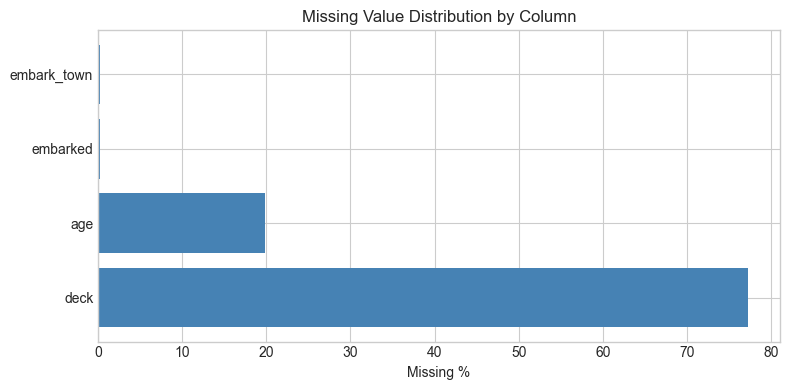

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df["missing_pct"], color="steelblue")
ax.set_xlabel("Missing %")
ax.set_title("Missing Value Distribution by Column")
plt.tight_layout()
plt.show()

In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Observations**

- `age` is missing ~20% of values — too important to drop, needs imputation
- `deck` is missing ~77% — likely too sparse to be useful, candidate for dropping
- `embarked` and `embark_town` are missing only 2 rows — safe to impute with mode
- `fare` and `age` are on very different scales — scaling will be necessary
- Several columns are duplicates in meaning: `embarked` / `embark_town`, `alive` / `survived`

## Data Cleaning

Handling missing values, duplicates, and dropping columns that are either redundant
or too sparse to be useful.

### Drop Irrelevant and Redundant Columns

`deck` has 77% missing — not recoverable. `embark_town` duplicates `embarked`.
`alive` duplicates `survived` as a string. `who` and `adult_male` are derivable
from `sex` and `age`. Dropping all of these keeps the dataset clean and non-redundant.

In [8]:
cols_to_drop = ["deck", "embark_town", "alive", "who", "adult_male"]
df = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {df.columns.tolist()}")
print(f"Shape after drop: {df.shape}")

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'alone']
Shape after drop: (891, 10)


### Remove Duplicates

Checking for fully duplicate rows before any imputation — duplicates after imputation
can be misleading.

In [9]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

df = df.drop_duplicates()
print(f"Shape after deduplication: {df.shape}")

Duplicate rows: 111
Shape after deduplication: (780, 10)


### Handle Missing Values

- `age` (~20% missing): impute with median — robust to the skew in age distribution
- `embarked` (2 rows missing): impute with mode — it is a low-cardinality categorical column

In [10]:
# Numeric imputation — median
age_imputer = SimpleImputer(strategy="median")
df["age"] = age_imputer.fit_transform(df[["age"]])

# Categorical imputation — mode
embarked_imputer = SimpleImputer(strategy="most_frequent")
df["embarked"] = embarked_imputer.fit_transform(df[["embarked"]]).ravel()

# Verify
print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("None remaining." if df.isnull().sum().sum() == 0 else "")

Missing values after imputation:
Series([], dtype: int64)
None remaining.


### Outlier Detection

Using IQR to detect outliers in `fare` and `age`. Detection only at this stage —
whether to remove or cap depends on the model being used downstream.

In [11]:
def iqr_outlier_summary(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, "
          f"lower={lower:.2f}, upper={upper:.2f}, outliers={outlier_count}")

iqr_outlier_summary("fare")
iqr_outlier_summary("age")

fare: Q1=8.05, Q3=34.38, IQR=26.32, lower=-31.44, upper=73.86, outliers=97
age: Q1=21.75, Q3=36.00, IQR=14.25, lower=0.38, upper=57.38, outliers=32


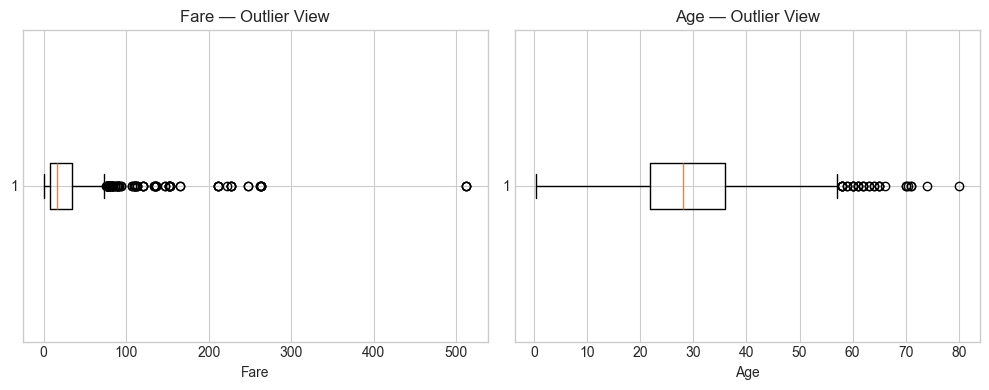

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df["fare"], vert=False)
axes[0].set_title("Fare — Outlier View")
axes[0].set_xlabel("Fare")

axes[1].boxplot(df["age"], vert=False)
axes[1].set_title("Age — Outlier View")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

**Observations**

- `fare` has significant right skew with several extreme values — RobustScaler will
  handle this better than StandardScaler downstream
- `age` outliers are mild and likely real data points (elderly passengers), not errors
- No rows removed at this stage — outlier treatment will be revisited when building
  the pipeline with a specific model in mind

## Scaler Selection Note — StandardScaler vs RobustScaler

### How StandardScaler Works

StandardScaler transforms each value using the column mean and standard deviation:

    scaled = (x - mean) / std_deviation

The problem is that both mean and std_deviation are sensitive to extreme values.
In the Titanic fare column, a handful of first-class passengers paid £500+.
That pulls the mean up from ~£14 (median) to ~£32, and inflates the std_deviation to ~£49.
Every ordinary passenger's fare now gets scaled relative to a distorted centre point.

### How RobustScaler Works

RobustScaler transforms each value using the median and IQR (interquartile range):

    scaled = (x - median) / IQR

The median is the middle value of the sorted data — extreme values cannot move it.
The IQR is the spread of the middle 50% of the data — extreme values sit outside it
and have no influence on it either.

### Why This Matters for Fare

| Statistic       | Value  |
|-----------------|--------|
| Mean fare       | ~£32   |
| Median fare     | ~£14   |
| Std deviation   | ~£49   |
| IQR             | ~£28   |

A fare of £7 scaled with StandardScaler: (7 - 32) / 49 = -0.51
A fare of £7 scaled with RobustScaler:  (7 - 14) / 28 = -0.25

The StandardScaler result is anchored to a mean that does not represent a typical
passenger. The RobustScaler result is anchored to the median fare of £14, which does.

### Conclusion

When a numeric column has significant right skew or visible outliers in the boxplot,
RobustScaler produces a more representative scaling because its reference points
(median and IQR) are outlier-resistant by definition.
StandardScaler remains the right choice when the distribution is approximately normal
and free of extreme values.

## Feature Encoding

Machine learning models require numeric input. Categorical columns need to be converted
to numbers — but the method matters. Choosing the wrong encoding can silently introduce
false relationships into the data.

| Encoding | When to Use |
|---|---|
| Label Encoding | Binary categories or when ordinality does not matter and tree models are used |
| Ordinal Encoding | Categories with a meaningful order (low, medium, high) |
| One-Hot Encoding | Nominal categories with no order — safe for linear models |

In [13]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns: {cat_cols}")

for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

Categorical columns: ['sex', 'embarked', 'class']

sex: <StringArray>
['male', 'female']
Length: 2, dtype: str

embarked: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

class: ['Third', 'First', 'Second']
Categories (3, str): ['First', 'Second', 'Third']


### Label Encoding

Assigns each unique category an integer. Fast and compact but implies an order
that may not exist. Safe for tree-based models (Random Forest, XGBoost) which
split on values and do not assume numeric distance means anything.

Applying to `sex` — binary column, no false ordinality introduced.

In [14]:
le = LabelEncoder()

df_le = df.copy()
df_le["sex_encoded"] = le.fit_transform(df_le["sex"])

print(df_le[["sex", "sex_encoded"]].drop_duplicates().sort_values("sex_encoded"))

      sex  sex_encoded
1  female            0
0    male            1


### Ordinal Encoding

Assigns integers according to a defined order. Unlike LabelEncoder, the order
is explicit and intentional.

`pclass` (passenger class) is 1, 2, 3 — already numeric but treated here as an
ordered category to demonstrate the pattern. A cleaner real-world example:
size = [small, medium, large] mapped to [0, 1, 2].

In [15]:
oe = OrdinalEncoder(categories=[[1, 2, 3]])

df_oe = df.copy()
df_oe["pclass_encoded"] = oe.fit_transform(df_oe[["pclass"]])

print(df_oe[["pclass", "pclass_encoded"]].drop_duplicates().sort_values("pclass"))

   pclass  pclass_encoded
1       1             0.0
9       2             1.0
0       3             2.0


### One-Hot Encoding

Creates a separate binary column for each category. No ordinal relationship is
implied. The right choice for nominal columns going into linear models or neural
networks.

Applying to `embarked` (S, C, Q). `drop="first"` removes one column to avoid
multicollinearity — if S=0 and C=0, the model already knows it is Q.

In [16]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

embarked_encoded = ohe.fit_transform(df[["embarked"]])
embarked_cols = ohe.get_feature_names_out(["embarked"])

df_ohe = df.copy()
df_ohe[embarked_cols] = embarked_encoded

print(df_ohe[["embarked"] + list(embarked_cols)].drop_duplicates().sort_values("embarked"))

  embarked  embarked_Q  embarked_S
1        C         0.0         0.0
5        Q         1.0         0.0
0        S         0.0         1.0


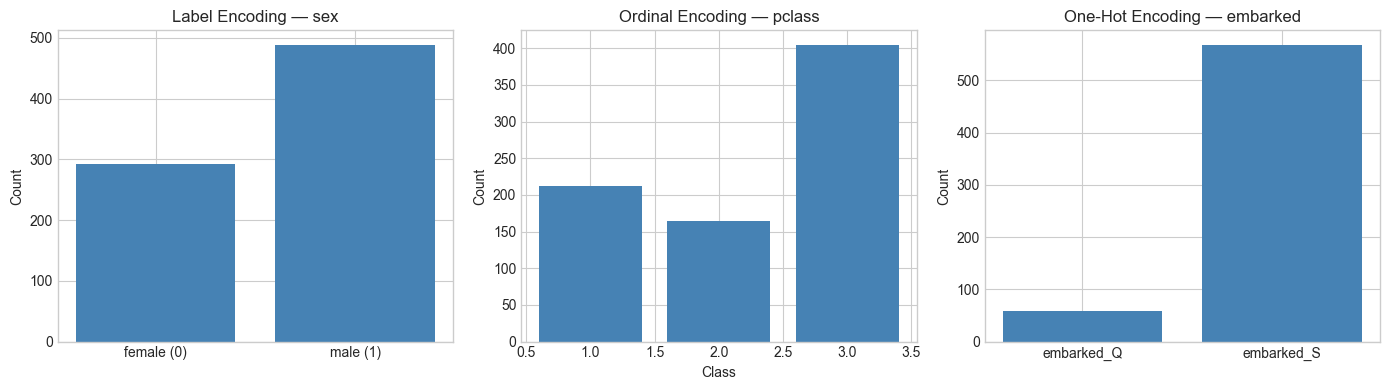

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Label encoding
axes[0].bar(df_le["sex_encoded"].value_counts().index,
            df_le["sex_encoded"].value_counts().values, color="steelblue")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["female (0)", "male (1)"])
axes[0].set_title("Label Encoding — sex")
axes[0].set_ylabel("Count")

# Ordinal encoding
axes[1].bar(df_oe["pclass"].value_counts().index,
            df_oe["pclass"].value_counts().values, color="steelblue")
axes[1].set_title("Ordinal Encoding — pclass")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

# One-hot encoding
ohe_sums = df_ohe[list(embarked_cols)].sum()
axes[2].bar(ohe_sums.index, ohe_sums.values, color="steelblue")
axes[2].set_title("One-Hot Encoding — embarked")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Observations**

- Label Encoding on `sex` is safe here — binary columns carry no false ordinality
  regardless of the 0/1 assignment
- Ordinal Encoding on `pclass` preserves the class hierarchy explicitly — class 1
  passengers are genuinely different from class 3 in a meaningful, ordered way
- One-Hot Encoding on `embarked` creates clean binary flags with no implied ranking
  between Southampton, Cherbourg, and Queenstown
- `drop="first"` on One-Hot Encoding is important for linear models to avoid the
  dummy variable trap — tree models do not need this but it does not hurt them either

## Feature Scaling

Numeric columns in the Titanic dataset are on very different scales — `age` ranges
from 0 to 80, `fare` from 0 to 512, `sibsp` and `parch` from 0 to 8. Models that
rely on distance or gradient calculations (Logistic Regression, KNN, SVM) are
sensitive to this. Tree-based models are not, but scaling never hurts them either.

Three scalers are compared here on the same columns so the differences are visible.

In [18]:
num_cols = ["age", "fare", "sibsp", "parch"]

print("Stats before scaling:")
df[num_cols].describe().round(2)

Stats before scaling:


,age,fare,sibsp,parch
count,780.00,780.00,780.00,780.00
mean,29.57,34.83,0.53,0.42
std,13.72,52.26,0.99,0.84
min,0.42,0.00,0.00,0.00
25%,21.75,8.05,0.00,0.00
50%,28.00,15.95,0.00,0.00
75%,36.00,34.38,1.00,1.00
max,80.00,512.33,8.00,6.00


### Applying StandardScaler, MinMaxScaler, and RobustScaler

Each scaler is fit and applied to the same numeric columns on a copy of the
dataframe so results can be compared side by side.

In [19]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
}

scaled_dfs = {}

for name, scaler in scalers.items():
    temp = df[num_cols].copy()
    scaled_values = scaler.fit_transform(temp)
    scaled_dfs[name] = pd.DataFrame(scaled_values, columns=num_cols)

print("Scaling applied for:", list(scaled_dfs.keys()))

Scaling applied for: ['StandardScaler', 'MinMaxScaler', 'RobustScaler']


In [20]:
for name, sdf in scaled_dfs.items():
    print(f"\n{name}:")
    print(sdf.describe().round(3))


StandardScaler:
           age     fare    sibsp    parch
count  780.000  780.000  780.000  780.000
mean     0.000   -0.000    0.000   -0.000
std      1.001    1.001    1.001    1.001
min     -2.126   -0.667   -0.532   -0.499
25%     -0.570   -0.513   -0.532   -0.499
50%     -0.115   -0.361   -0.532   -0.499
75%      0.469   -0.009    0.480    0.695
max      3.677    9.142    7.570    6.661

MinMaxScaler:
           age     fare    sibsp    parch
count  780.000  780.000  780.000  780.000
mean     0.366    0.068    0.066    0.070
std      0.172    0.102    0.124    0.140
min      0.000    0.000    0.000    0.000
25%      0.268    0.016    0.000    0.000
50%      0.347    0.031    0.000    0.000
75%      0.447    0.067    0.125    0.167
max      1.000    1.000    1.000    1.000

RobustScaler:
           age     fare    sibsp    parch
count  780.000  780.000  780.000  780.000
mean     0.110    0.717    0.526    0.418
std      0.963    1.985    0.988    0.839
min     -1.935   -0.606    0.

### Visual Comparison

Plotting the distribution of `fare` and `age` after each scaler. `fare` has heavy
right skew and outliers. `age` is more normally distributed. The plots make it
clear how each scaler handles these two different situations.

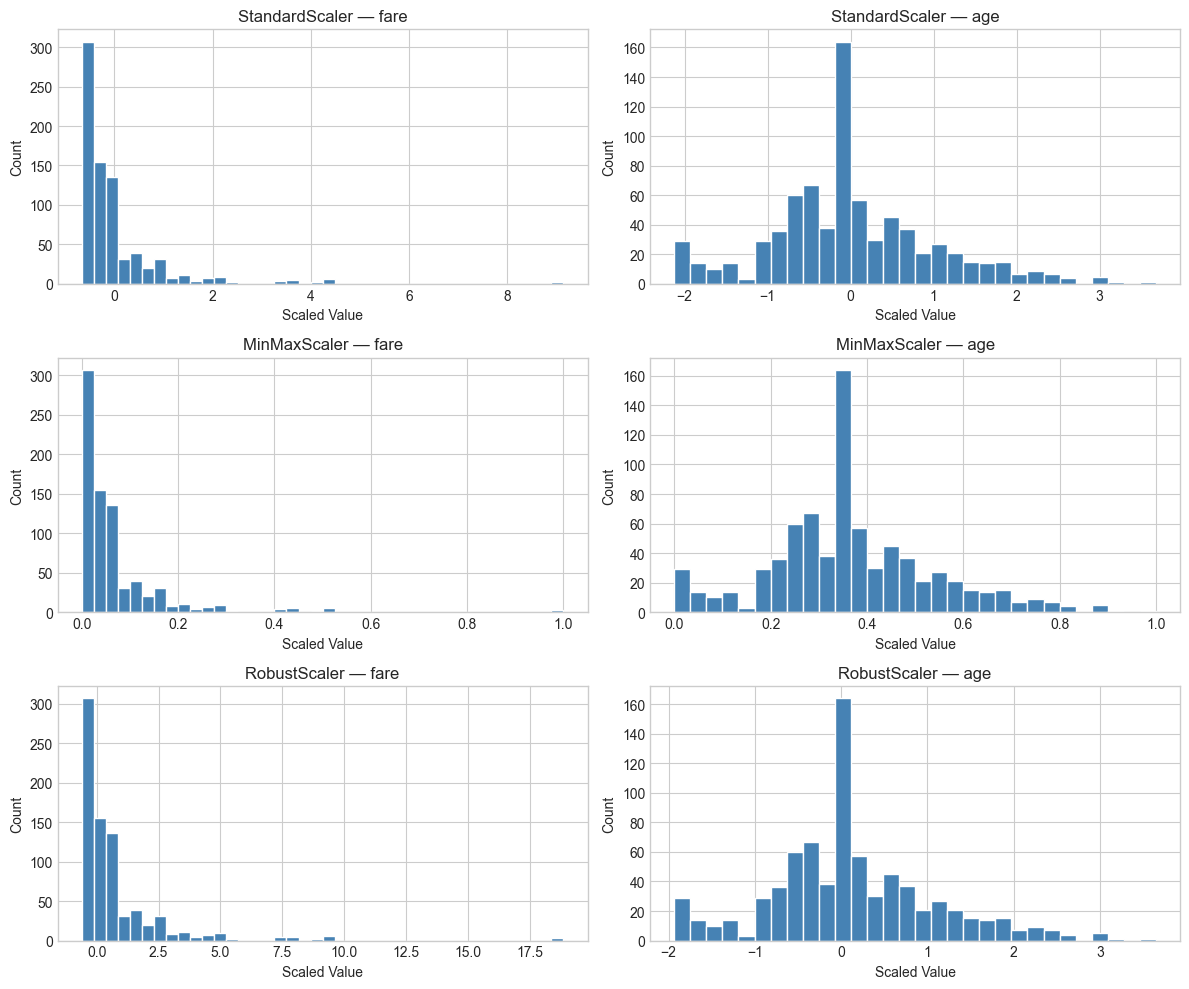

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

scaler_names = list(scaled_dfs.keys())

for row, name in enumerate(scaler_names):
    sdf = scaled_dfs[name]

    axes[row, 0].hist(sdf["fare"], bins=40, color="steelblue", edgecolor="white")
    axes[row, 0].set_title(f"{name} — fare")
    axes[row, 0].set_xlabel("Scaled Value")
    axes[row, 0].set_ylabel("Count")

    axes[row, 1].hist(sdf["age"], bins=30, color="steelblue", edgecolor="white")
    axes[row, 1].set_title(f"{name} — age")
    axes[row, 1].set_xlabel("Scaled Value")
    axes[row, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

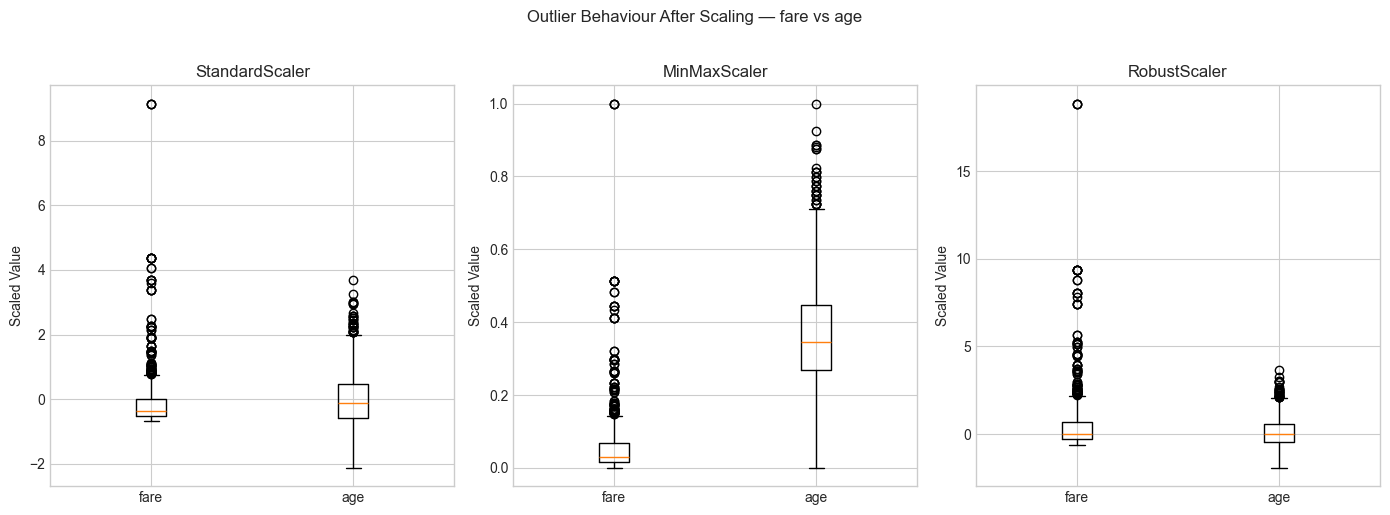

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for col_idx, name in enumerate(scaler_names):
    axes[col_idx].boxplot(
        [scaled_dfs[name]["fare"], scaled_dfs[name]["age"]],
        labels=["fare", "age"]
    )
    axes[col_idx].set_title(name)
    axes[col_idx].set_ylabel("Scaled Value")

plt.suptitle("Outlier Behaviour After Scaling — fare vs age", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- StandardScaler centres both columns at 0 but fare's outliers stretch the axis
  significantly — the bulk of fare values are compressed near 0
- MinMaxScaler forces all values into [0, 1] — clean and bounded, but a single
  extreme fare value of £512 pushes every other fare toward 0
- RobustScaler keeps the bulk of fare values in a compact, readable range — outliers
  are still present but they no longer distort the scaling of typical values
- For `age`, all three scalers perform similarly because the distribution is
  reasonably normal with no severe outliers — this confirms StandardScaler is
  fine for well-behaved columns
- Conclusion for this dataset: RobustScaler for `fare`, StandardScaler or
  RobustScaler for `age`, MinMaxScaler only if a bounded [0,1] output is
  specifically required by the model

## A Clean Preprocessing Pipeline

All the steps covered so far — imputation, encoding, scaling — are combined into a
single sklearn Pipeline using ColumnTransformer. This is the production-ready pattern:
no manual column-by-column transformations, no data leakage from fitting on the full
dataset, and a clean train/test split.

### Column Definitions

Separating columns by the transformation they need. This is the map the
ColumnTransformer will follow.

In [24]:
# Target
TARGET = "survived"

# Numeric columns — impute with median, scale with RobustScaler
numeric_cols = ["age", "fare", "sibsp", "parch"]

# Binary categorical — impute with most_frequent, label encode
binary_cols = ["sex"]

# Nominal categorical — impute with most_frequent, one-hot encode
nominal_cols = ["embarked"]

# Ordinal categorical — already numeric, include as-is after imputation
ordinal_cols = ["pclass"]

# Columns to drop — redundant or too sparse
drop_cols = ["deck", "embark_town", "alive", "who", "adult_male"]

print("Column mapping defined.")

Column mapping defined.


### Train / Test Split

The split happens before fitting any transformer. Fitting on the full dataset
would leak test set statistics (mean, median, category frequencies) into the
training process — a subtle but real form of data leakage.

In [26]:
from sklearn.model_selection import train_test_split

raw_df = sns.load_dataset("titanic").drop(columns=drop_cols)

X = raw_df.drop(columns=[TARGET])
y = raw_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train survived rate: {y_train.mean():.2f}")
print(f"y_test  survived rate: {y_test.mean():.2f}")

X_train: (712, 9)  X_test: (179, 9)
y_train survived rate: 0.38
y_test  survived rate: 0.39


### ColumnTransformer

Each transformer is applied only to its designated columns. `remainder="drop"`
discards any column not explicitly listed — keeps the output clean and predictable.

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder()),
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", sparse_output=False)),
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric",  numeric_transformer,  numeric_cols),
        ("binary",   binary_transformer,   binary_cols),
        ("nominal",  nominal_transformer,  nominal_cols),
        ("ordinal",  ordinal_transformer,  ordinal_cols),
    ],
    remainder="drop"
)

print("Preprocessor defined.")

Preprocessor defined.


### Fit on Train, Transform Both Sets

`fit_transform` on the training set learns all parameters (medians, category
mappings, IQR values). `transform` on the test set applies those same learned
parameters — the test set never influences the fit.

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Reconstruct column names for readability
ohe_cols = preprocessor.named_transformers_["nominal"]["encoder"].get_feature_names_out(nominal_cols).tolist()
all_cols = numeric_cols + binary_cols + ohe_cols + ordinal_cols

df_train_processed = pd.DataFrame(X_train_processed, columns=all_cols)

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")
print(f"\nSample processed training rows:")
df_train_processed.head()

Processed train shape: (712, 8)
Processed test shape:  (179, 8)

Sample processed training rows:


,age,fare,sibsp,parch,sex,embarked_Q,embarked_S,pclass
0,0.000000,1.819652,0.0,0.0,1.0,0.0,1.0,3.0
1,0.000000,-0.625609,0.0,0.0,1.0,0.0,1.0,2.0
2,0.000000,8.973477,0.0,0.0,1.0,0.0,1.0,1.0
3,-0.750000,-0.220921,0.0,1.0,0.0,0.0,1.0,3.0
4,0.178571,0.510548,1.0,1.0,0.0,0.0,1.0,2.0


In [29]:
missing_train = pd.DataFrame(X_train_processed, columns=all_cols).isnull().sum().sum()
missing_test  = pd.DataFrame(X_test_processed,  columns=all_cols).isnull().sum().sum()

print(f"Missing values in processed train: {missing_train}")
print(f"Missing values in processed test:  {missing_test}")

Missing values in processed train: 0
Missing values in processed test:  0


**Observations**

- The pipeline fits only on training data — no information from the test set
  influences any transformation parameter
- All missing values are resolved through the imputation steps inside each
  sub-pipeline
- The final output is a clean numeric matrix ready to be passed directly into
  any sklearn model
- Reusing this preprocessor in future notebooks only requires calling
  `preprocessor.transform(X_new)` — no steps need to be repeated manually

## Key Takeaways

### Data Cleaning
- Drop columns with >50% missing values — imputation cannot recover what is not there
- Always check for redundant columns before modelling — `alive` and `survived` carry
  identical information and would inflate feature importance scores
- Detect outliers before choosing a scaler — the boxplot is the fastest way to make
  that decision
- Remove duplicates before imputation, not after

### Feature Encoding
- Label Encoding is safe for binary columns and tree-based models only — it silently
  introduces ordinality that linear models will misinterpret
- Ordinal Encoding requires you to define the order explicitly — never let the encoder
  infer it from alphabetical sorting
- One-Hot Encoding with `drop="first"` avoids the dummy variable trap for linear models
- Tree-based models are indifferent to encoding choice — linear models are not

### Feature Scaling
- StandardScaler is the default for normally distributed columns with no extreme outliers
- RobustScaler is the right choice when boxplots show significant skew or outliers
- MinMaxScaler is appropriate only when the model explicitly requires bounded [0, 1] input
- Scaling never hurts tree-based models but is mandatory for distance and gradient based models

### The Preprocessing Pipeline
- Always split before fitting any transformer — fitting on the full dataset leaks test
  set statistics into the training process
- ColumnTransformer applies different transformations to different column groups in one
  clean pass
- A fitted preprocessor is reusable — `transform(X_new)` applies all learned parameters
  to any new data without repeating any steps